# LAB 4 ML K240041

In [78]:
!unzip /content/data.zip

Archive:  /content/data.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/data.zip or
        /content/data.zip.zip, and cannot find /content/data.zip.ZIP, period.


In [79]:
import pandas as pd

In [80]:
df_train = pd.read_csv("/content/train.csv")
df_test_true = pd.read_csv("/content/test.csv")


In [81]:
df_train

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,1
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1


In [82]:
df_train.describe()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,691369.000000,662440.000000,595515.000000,557374.000000,564548.000000,639851.000000,646889.000000,623785.000000,610659.000000,579306.000000,691369.000000
mean,345684.000000,26.615408,7.640865,2.471038,1.459265,2.366971,6.804334,145.894900,102.636781,9.479866,0.709424
std,199581.183466,5.153162,2.721446,1.316137,0.934552,1.258797,1.234512,65.917556,48.093970,2.856006,0.454028
min,0.000000,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,0.000000
25%,172842.000000,22.000000,5.480000,1.450000,0.700000,1.360000,5.780000,93.000000,64.000000,7.280000,0.000000
50%,345684.000000,27.000000,7.770000,2.310000,1.330000,2.200000,6.800000,150.000000,104.000000,9.580000,1.000000
75%,518526.000000,31.000000,9.840000,3.370000,2.090000,3.200000,7.870000,204.000000,145.000000,11.750000,1.000000
max,691368.000000,35.000000,15.000000,8.000000,4.000000,6.000000,9.000000,250.000000,180.000000,17.560000,1.000000


In [83]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [84]:
df_train.isnull().sum()

,0
id,0
age,28929
daily_screen_time_hours,95854
social_media_hours,133995
gaming_hours,126821
work_study_hours,51518
sleep_hours,44480
notifications_per_day,67584
app_opens_per_day,80710
weekend_screen_time,112063


FIXING MISSING VALUES

In [85]:
df_train.columns

Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'gender', 'stress_level', 'academic_work_impact', 'addicted_label'],
      dtype='object')

In [86]:
for col in df_train.columns:
  print(col)

id
age
daily_screen_time_hours
social_media_hours
gaming_hours
work_study_hours
sleep_hours
notifications_per_day
app_opens_per_day
weekend_screen_time
gender
stress_level
academic_work_impact
addicted_label


In [87]:
import pandas as pds

# Separate numerical and categorical columns
numeric_cols = df_train.select_dtypes(include=['number']).columns
categorical_cols = df_train.select_dtypes(include=['object']).columns

# Fill missing values in numerical columns with their mean
for col in numeric_cols:
  df_train[col] = df_train[col].fillna(df_train[col].mean())

# Fill missing values in categorical columns with their mode
for col in categorical_cols:
  # Using .iloc[0] to get the first mode in case of multiple modes
  df_train[col] = df_train[col].fillna(df_train[col].mode()[0])

In [88]:
df_train.isnull().sum()

,0
id,0
age,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0
app_opens_per_day,0
weekend_screen_time,0


SPLITTING THE DF


# ENCODING DATA SUCH AS GENDER STRESS LEVEL

USING LABEL ENCODER


In [89]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_train['gender'] = le.fit_transform(df_train['gender'])
df_train['stress_level'] = le.fit_transform(df_train['stress_level'])
df_train['academic_work_impact'] = le.fit_transform(df_train['academic_work_impact'])

df_train


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.000000,7.640865,1.830000,1.590000,2.110000,7.46,122.0000,38.000000,8.630000,1,2,0,1
1,1,19.000000,5.970000,1.080000,1.459265,3.030000,8.22,76.0000,19.000000,9.479866,0,2,0,0
2,2,18.000000,5.090000,2.471038,1.459265,2.366971,6.25,134.0000,60.000000,7.470000,0,1,1,0
3,3,21.000000,6.420000,1.260000,1.420000,3.360000,8.85,112.0000,94.000000,8.660000,2,1,1,1
4,4,26.000000,11.200000,1.870000,2.810000,1.950000,5.25,145.8949,102.636781,13.390000,0,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.000000,10.780000,3.250000,1.570000,1.650000,7.71,86.0000,94.000000,12.890000,1,0,0,1
691365,691365,20.000000,3.450000,1.860000,0.890000,0.300000,6.59,221.0000,42.000000,8.470000,0,0,0,1
691366,691366,26.615408,7.640865,2.471038,1.459265,2.060000,6.16,145.8949,86.000000,7.790000,2,2,0,1
691367,691367,22.000000,11.780000,3.690000,0.230000,1.350000,5.53,171.0000,62.000000,7.710000,2,0,1,1


In [90]:
df_train['addicted_label'] = df_train['addicted_label'].astype(str)

TRAINING DECISION TREE

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score

In [91]:
from sklearn.model_selection import train_test_split

yTrain,xTrain = df_train['addicted_label'],df_train.drop(['addicted_label'],axis=1)


X_train, X_test, y_train, y_test = train_test_split(
    xTrain, yTrain, test_size=0.2, random_state=42
)

In [92]:
from sklearn.tree import DecisionTreeClassifier



dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [93]:
dt_model.predict(X_test)

array(['0', '1', '0', ..., '1', '1', '1'], dtype=object)

In [94]:
yTrain

,addicted_label
0,1
1,0
2,0
3,1
4,1
...,...
691364,1
691365,1
691366,1
691367,1


In [95]:
y_test.name

'addicted_label'

In [96]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree


KeyboardInterrupt: 

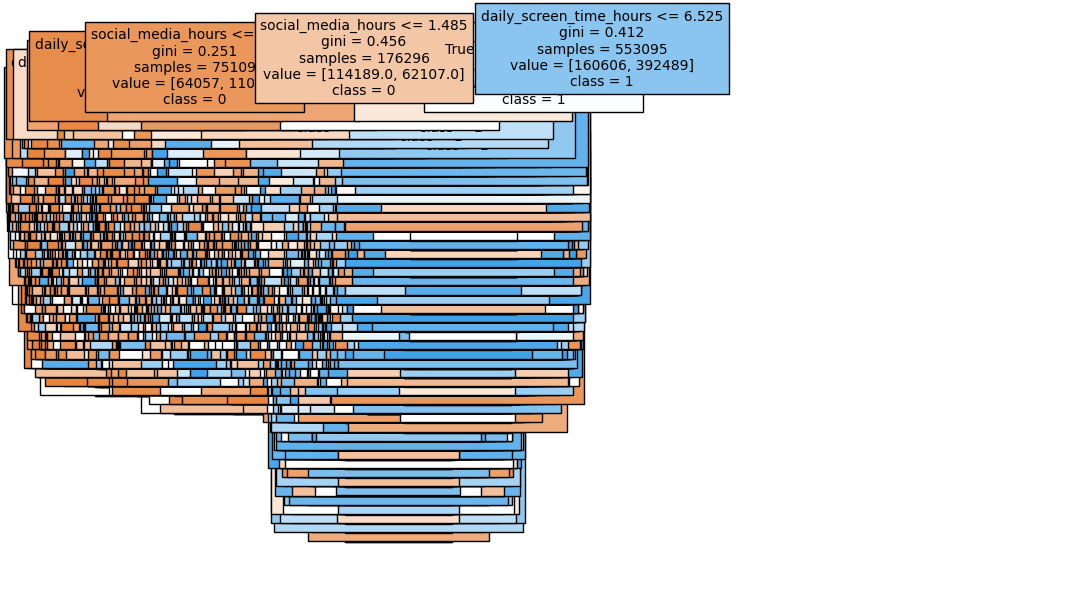

In [77]:
plt.figure(figsize=(12, 7))

plot_tree(
    dt_model,
    feature_names=xTrain.columns,
    class_names=['0','1'],
    filled=True
)

plt.show()

# GradientBoostingRegressor

In [97]:
from sklearn.ensemble import GradientBoostingRegressor

reg = GradientBoostingRegressor(random_state=0)
reg.fit(X_train, y_train)

reg.predict(X_test[1:2])
reg.score(X_test, y_test)

0.5385319294409977

# XG BOOST

In [ ]:
from xgboost import XGBClassifier

bst = XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic')
# fit model
bst.fit(X_train, y_train)
# make predictions
preds = bst.predict(X_test)

# LIGHT BGM

In [98]:
import lightgbm as lgb

train_data=lgb.Dataset(X_train,label=y_train)
valid_data=lgb.Dataset(X_test,label=y_test,reference=train_data)



params={
"objective":"binary",
"metric":["auc","binary_logloss"],
"boosting_type":"gbdt",
"learning_rate":0.05,
"num_leaves":31,
"max_depth":-1,
"feature_fraction":0.8,
"bagging_fraction":0.8,
"bagging_freq":5,
"lambda_l1":0.1,
"lambda_l2":0.2,
"min_data_in_leaf":20,
"verbose":-1
}

In [ ]:
model=lgb.train(
params,
train_data,
num_boost_round=1000,
valid_sets=[train_data,valid_data],
valid_names=["train","valid"],
callbacks=[lgb.early_stopping(50)]
)

In [ ]:
y_pred_prob=model.predict(X_test,num_iteration=model.best_iteration)
y_pred=(y_pred_prob>0.5).astype(int)

In [ ]:
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
auc=roc_auc_score(y_test,y_pred_prob)

print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)
print("AUC:",auc)

In [ ]:
print(classification_report(y_test,y_pred))